# **Project 2: Heart Disease**

## Importing libraries and data set

In [27]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [28]:
# Load in our dataset
df = pd.read_csv("Heart_Disease_Prediction.csv")
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


## Data Cleaning

In [29]:
#convert if heart disease is present to numbers to be able to use machine learning
df['Heart Disease']=df['Heart Disease'].map({'Presence':1, 'Absence':0})

In [30]:
df.head() #check to see

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [31]:
#check for missing values
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [32]:
# add a "_" instead of spaces to titles
df.columns = df.columns.str.replace(' ', '_')

## Train/test split

In [33]:
X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [35]:
#train data
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# see accuracy of trained data
accuracy=model.score(X_test, y_test)
print(f"Accuracy Score: {accuracy}")

Accuracy Score: 0.6851851851851852


In [36]:
# Predict on the test set
y_pred = model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy}")

Accuracy Score: 0.6851851851851852


In [38]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[22 11]
 [ 6 15]]


## Experiments

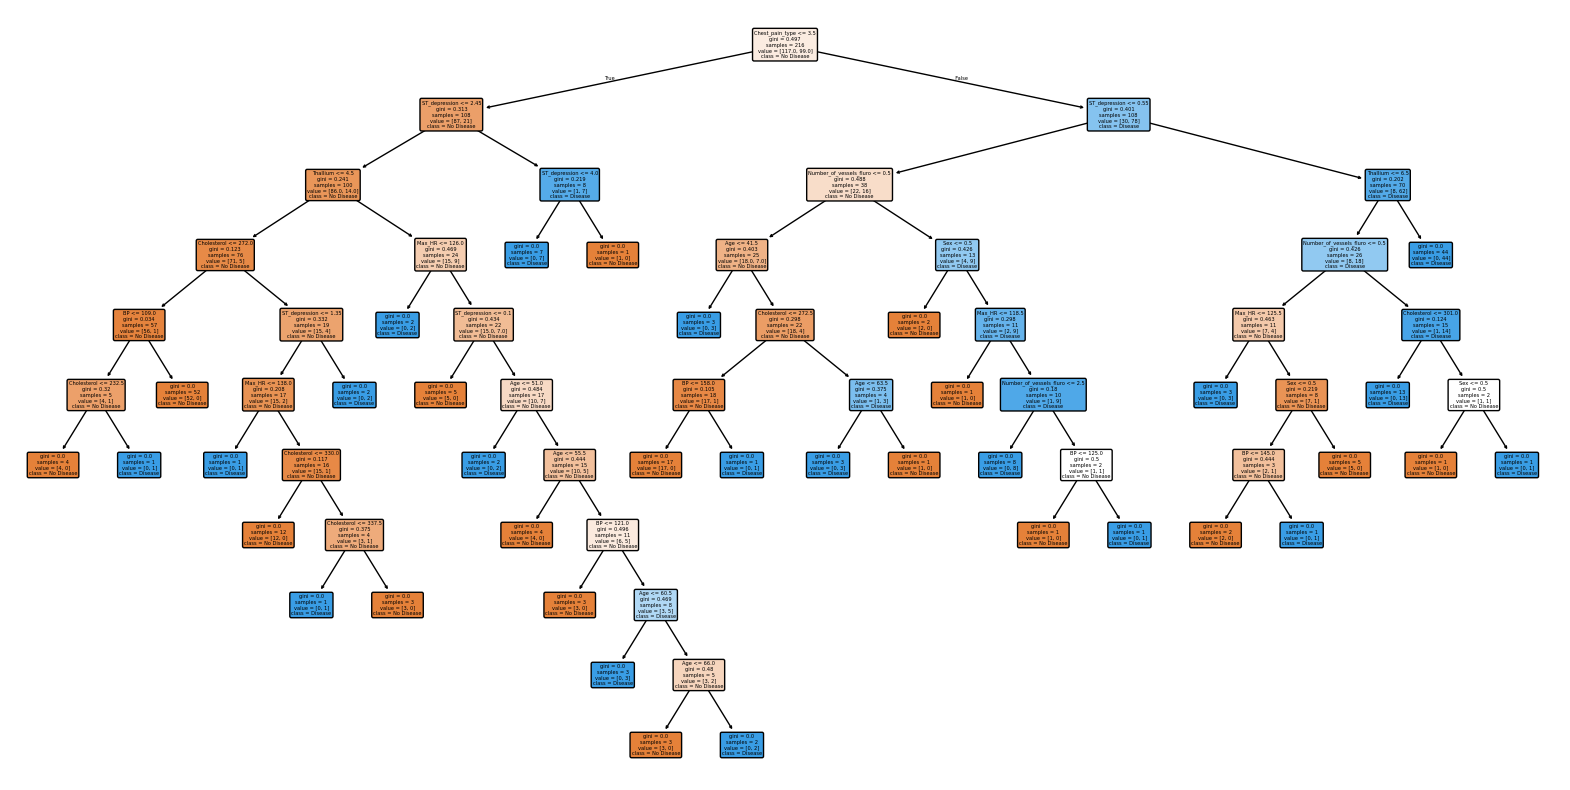

In [39]:
#visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No Disease','Disease'], filled=True, rounded=True)
plt.show()

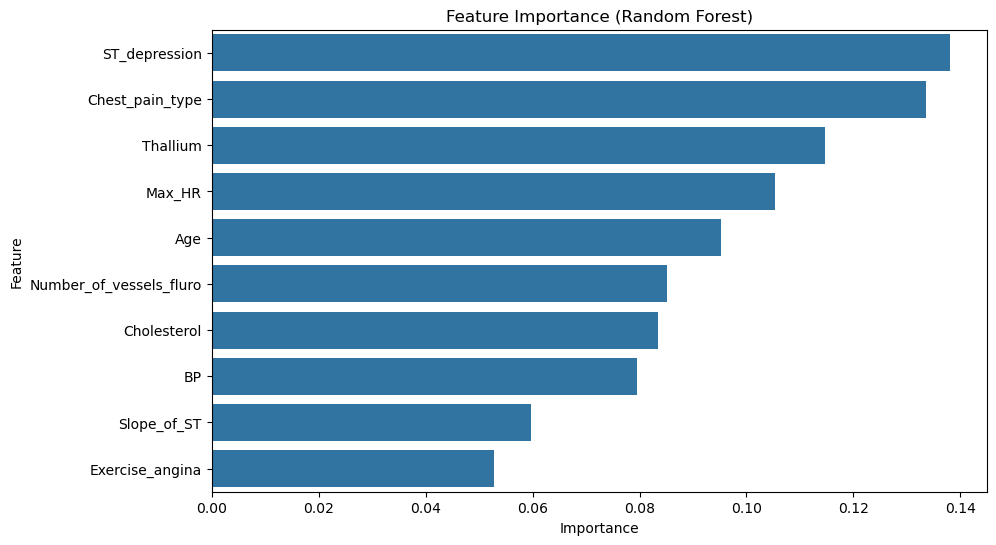

In [60]:
#Random forest 
importances = rf_model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10))
plt.title("Feature Importance (Random Forest)")
plt.show()

In [59]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train logistic regression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9259259259259259
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54



In [40]:
#precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.5769230769230769


In [43]:
#recall, high recall= good, hows the percentage of how many people were correctly diagnosed with heart disease from the model
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.7142857142857143


In [42]:
#f1 score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6382978723404256


## Visualizations

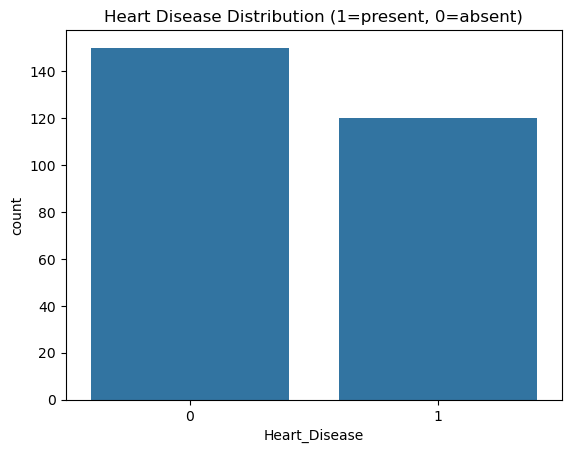

In [62]:
sns.countplot(x='Heart_Disease', data=df)
plt.title("Heart Disease Distribution (1=present, 0=absent)")
plt.show()

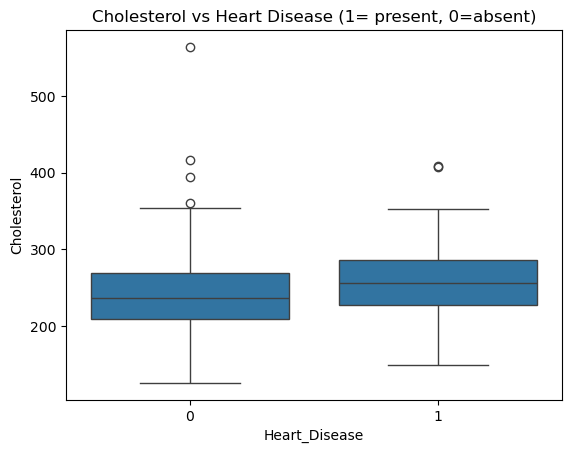

In [46]:
sns.boxplot(x='Heart_Disease', y='Cholesterol', data=df)
plt.title("Cholesterol vs Heart Disease (1= present, 0=absent)")
plt.show()

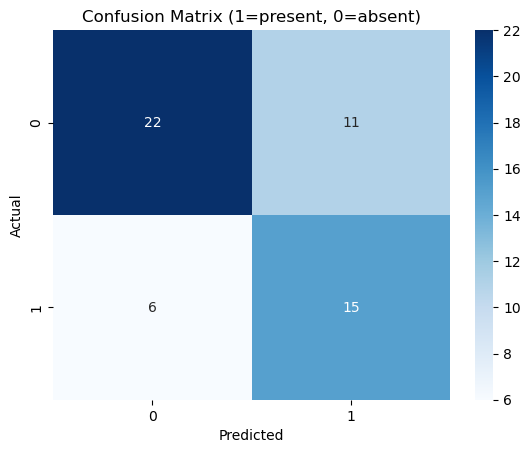

In [49]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (1=present, 0=absent)")
plt.show()

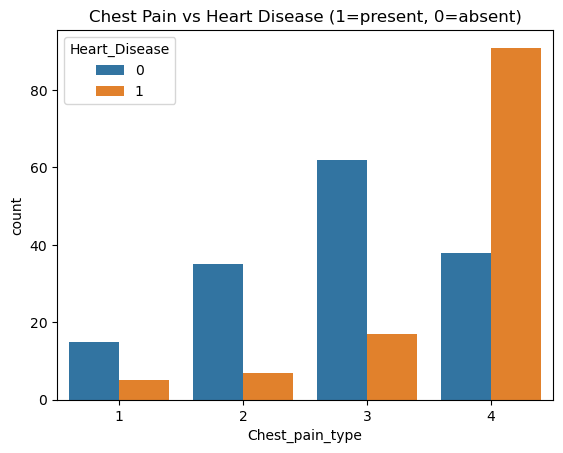

In [61]:
sns.countplot(x='Chest_pain_type', hue='Heart_Disease', data=df)
plt.title("Chest Pain vs Heart Disease (1=present, 0=absent)")
plt.show()